# Taxonomy induction on Amazon-C4, from the items alone

jevqu builds the taxonomy itself. `create_query_understanding` sees only the collection, never a query:

1. **Propose.** Cluster a sample of items by their embeddings and name each cluster from its distinctive words.
2. **Size gate.** Jev scores every sampled item against every candidate; a candidate is kept if it covers 0.5% to 40% of items, so payload-filtered search stays fast.
3. **Judge gate (variant B only).** Jev looks at each candidate with the store around it and answers two questions: would shoppers search for this kind of product, and do its example items form one kind of product.

Variant A uses the size gate only. Variant B adds the judge gate. Both are then used to label all 20,000 items and are scored on 300 held-out queries, against plain hybrid search and against the result with Amazon's own departments (+3.9 nDCG@10, from `jevqu_c4_demo.ipynb`).

**Cost**, priced from the real requests: step 1 about $0.78, step 2 between $0.92 (10 classes kept) and $3.19 (all 40 kept), step 3 a few cents. Each step prices a small uncached pilot first and stops if the extrapolated cost exceeds `JEVQU_MAX_USD` (default $10).

In [1]:
import csv, dataclasses, json, os, random, sys, tempfile, time, urllib.request, warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")        # tqdm without ipywidgets
warnings.filterwarnings("ignore", message="Payload indexes have no effect")  # in-memory Qdrant only

import matplotlib.pyplot as plt
import numpy as np
from fastembed import SparseTextEmbedding, TextEmbedding
from IPython.display import Markdown, display
from qdrant_client import QdrantClient, models

ROOT = Path.cwd() if (Path.cwd() / "jevqu").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
for line in (ROOT / ".env").read_text().splitlines() if (ROOT / ".env").exists() else []:
    key, _, value = line.partition("=")
    if key.strip() and not key.lstrip().startswith("#"):
        os.environ.setdefault(key.strip(), value.strip().strip("'\""))

from jevqu import JEV_MODEL
from jevqu.api import _sample, create_query_understanding, set_query_understanding, understand_query, upload_points
from jevqu.classify import classify_point
from jevqu.induce import coverage, propose
from jevqu.jev import Jev
from jevqu.metrics import ndcg_at_k, paired_bootstrap, recall_at_k
from jevqu.qquery import build_filter, run
from jevqu.schema import Taxonomy, Thresholds, Understanding
from jevqu.text import state_from_payload

SEED = 0
N_QUERIES = 300           # evaluation queries: used only in step 3, never during induction
N_POINTS = 20_000         # the same collection as jevqu_c4_demo.ipynb
SAMPLE = 5_000            # items create_query_understanding looks at
K = 40                    # candidate groups proposed by clustering
USE_JEV = bool(os.environ.get("OPENROUTER_API_KEY"))
MAX_USD = float(os.environ.get("JEVQU_MAX_USD", "10"))
WORKERS = 8
DATA = ROOT / "data" / "c4"
COLLECTION = "c4-induced"
REFERENCE = {"filter every guess": (0.039, 0.022, 0.055), "jevqu auto": (0.013, 0.005, 0.021)}  # Amazon's departments, Jev run
print("classifier:", f"Jev ({JEV_MODEL}) on OpenRouter" if USE_JEV else "offline stand-in (no OPENROUTER_API_KEY)")

classifier: Jev (typesafe/jev-1.13) on OpenRouter


## 1. The collection

The same 300 queries and 20,000 items as the department demo: each query's target item plus a uniform sample of C4's 1M-item pool. Items carry only their text; Amazon's department is used only to describe the classes afterwards.

In [2]:
BASE = "https://huggingface.co/datasets/McAuley-Lab/Amazon-C4/resolve/main/"
DATA.mkdir(parents=True, exist_ok=True)
csv.field_size_limit(sys.maxsize)
for local, remote in [("test.csv", "test.csv"), ("items.jsonl", "sampled_item_metadata_1M.jsonl")]:
    if not (DATA / local).exists():
        urllib.request.urlretrieve(BASE + remote, DATA / local)

rng = random.Random(SEED)
with open(DATA / "test.csv", newline="") as f:
    c4_queries = list(csv.DictReader(f))
evalq = rng.sample(c4_queries, N_QUERIES)
targets = {q["item_id"] for q in evalq}
items, pool, seen = {}, [], 0
with open(DATA / "items.jsonl") as f:
    for line in f:
        d = json.loads(line)
        if d["item_id"] in targets:
            items[d["item_id"]] = d
            continue
        seen += 1
        if len(pool) < N_POINTS:
            pool.append(d)
        elif (j := rng.randrange(seen)) < N_POINTS:
            pool[j] = d
for d in pool[: N_POINTS - len(items)]:
    items[d["item_id"]] = d
catalog = list(items.values())
pid = {d["item_id"]: n for n, d in enumerate(catalog)}
qtexts = [q["query"] for q in evalq]
relevant = [{pid[q["item_id"]]} for q in evalq]

def text(d):
    return d["metadata"][:600]

def title(d):
    return d["metadata"].split(". ")[0][:80]

def sparse_vec(s):
    return models.SparseVector(indices=s.indices.tolist(), values=s.values.tolist())

dense, bm25 = TextEmbedding("BAAI/bge-small-en-v1.5"), SparseTextEmbedding("Qdrant/bm25")
cache = DATA / f"dense_{SEED}_{N_QUERIES}_{N_POINTS}.npy"
if cache.exists():
    dvecs = np.load(cache)
else:
    dvecs = np.array(list(dense.embed([text(d) for d in catalog], batch_size=64)))
    np.save(cache, dvecs)
svecs = list(bm25.embed([text(d) for d in catalog]))

client = QdrantClient(url=os.environ["QDRANT_URL"]) if os.environ.get("QDRANT_URL") else QdrantClient(":memory:")
if client.collection_exists(COLLECTION):
    client.delete_collection(COLLECTION)
client.create_collection(COLLECTION,
    vectors_config={"dense": models.VectorParams(size=dvecs.shape[1], distance=models.Distance.COSINE)},
    sparse_vectors_config={"sparse": models.SparseVectorParams(modifier=models.Modifier.IDF)})
points = [models.PointStruct(id=pid[d["item_id"]], vector={"dense": v.tolist(), "sparse": sparse_vec(s)},
                             payload={"item_id": d["item_id"], "text": text(d)})
          for d, v, s in zip(catalog, dvecs, svecs)]
client.upsert(COLLECTION, points)
print(f"{len(points):,} items indexed, {len(evalq)} evaluation queries")

20,000 items indexed, 300 evaluation queries


## 2. The classifier

With a key, Jev (`typesafe/jev-1.13`) through OpenRouter. Without one, a word-matching stand-in that only proves the notebook runs: its numbers mean nothing.

In [3]:
class OfflineStandIn:
    # Says yes when words of the class name appear in the text. Only for checking that the notebook runs.
    model = "offline"

    def ask(self, state, questions):
        blob = json.dumps(state).lower()
        out = {}
        for qid, q in questions.items():
            words = q["instructions"].split("`")[1].lower().split() if "`" in q["instructions"] else None
            hits = sum(w in blob for w in words) if words else 0
            p = 0.6 if words is None else 0.95 if hits >= 2 else 0.7 if hits == 1 else 0.05
            out[qid] = {"type": "noul", "noul": p}
        return out

jev = Jev(cache_dir=ROOT / ".jev_cache") if USE_JEV else OfflineStandIn()

def spent():
    return sum(getattr(jev, "usage", []))

def price_check(label, pilot_fn, n_pilot, n_total):
    # prices n_pilot fresh (uncached) requests and stops before a run above MAX_USD
    if not USE_JEV:
        return
    with tempfile.TemporaryDirectory() as d:
        fresh = Jev(cache_dir=d)
        pilot_fn(fresh)
    estimate = sum(fresh.usage) / n_pilot * n_total
    print(f"{label}: about ${estimate:.2f} for {n_total:,} requests (pilot of {n_pilot}, upper bound: cached answers are free)")
    assert estimate <= MAX_USD, f"estimate is above JEVQU_MAX_USD=${MAX_USD:.0f}"

## 3. Step 1: induce the classes, both variants

`create_query_understanding` gets the collection and Jev, nothing else. The price check rebuilds the same 40 candidates and prices 10 of the 5,000 coverage requests. Variant B's coverage answers come from the cache that variant A just filled, so B adds only its 40 judge requests.

In [4]:
pts = _sample(client, COLLECTION, SAMPLE)
states = [state_from_payload(p.payload) for p in pts]
texts = [" ".join(str(v) for v in st.values() if isinstance(v, str)) for st in states]
cands = propose(texts, np.array([p.vector["dense"] for p in pts]), k=K)
print(f"{len(cands)} candidates, for example: {', '.join(c.id for c in cands[:8])}")
price_check("step 1, coverage", lambda fresh: coverage(cands, states[:10], fresh, workers=WORKERS), 10, SAMPLE)

t0, s0 = time.time(), spent()
tax_a, report_a = create_query_understanding(client, COLLECTION, jev, sample=SAMPLE, k=K, workers=WORKERS)
tax_b, report_b = create_query_understanding(client, COLLECTION, jev, sample=SAMPLE, k=K, workers=WORKERS, judge_groups=True)
print(f"variant A keeps {len(tax_a.classes)}, variant B keeps {len(tax_b.classes)} of {len(report_a)} candidates "
      f"in {time.time() - t0:.0f}s" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))

40 candidates, for example: kitchen-food-stainless-steel, dog-pet-toy-dogs, shoes-women-men-shoe, garden-plants-plant-artificial, spanish-edition-para-practical, child-kids-bunny-tale, author-review-book-books, curtain-inch-room-window
step 1, coverage: about $0.64 for 5,000 requests (pilot of 10, upper bound: cached answers are free)
variant A keeps 24, variant B keeps 19 of 40 candidates in 203s, $0.6479


In [5]:
b = {r["id"]: r for r in report_b}
rows = ["| candidate | coverage | popular | coherent | A | B |", "|---|---|---|---|---|---|"]
for r in sorted(report_a, key=lambda r: -r["coverage"]):
    rb = b[r["id"]]
    mark = lambda row: "kept" if row["kept"] else row["rejected_by"]
    rows.append(f"| {r['name']} | {r['coverage']:.1%} | {rb.get('popular', 0):.2f} | {rb.get('coherent', 0):.2f} | "
                f"{mark(r)} | {mark(rb)} |")
display(Markdown("\n".join(rows)))

| candidate | coverage | popular | coherent | A | B |
|---|---|---|---|---|---|
| Shoes Women Men Shoe | 3.7% | 0.85 | 0.94 | kept | kept |
| Storage Organizer Holder Shelf | 3.3% | 0.85 | 0.47 | kept | judge |
| Replacement Compatible Oem Vehicle | 2.8% | 0.81 | 0.91 | kept | kept |
| Review Author Book Guide | 2.7% | 0.57 | 0.84 | kept | kept |
| Led Light Lights Lighting | 2.3% | 0.92 | 0.90 | kept | kept |
| Bag Bags Travel Storage | 2.1% | 0.84 | 0.65 | kept | kept |
| Toys Kids Toy Boys | 1.9% | 0.58 | 0.73 | kept | kept |
| Author Review Book Books | 1.6% | 0.59 | 0.89 | kept | kept |
| Christmas Party Decoration Decorations | 1.5% | 0.64 | 0.76 | kept | kept |
| Women Sleeve Neck Tops | 1.4% | 0.73 | 0.91 | kept | kept |
| Dog Dogs Collar Pet | 1.4% | 0.84 | 0.37 | kept | judge |
| Kitchen Food Stainless Steel | 1.2% | 0.71 | 0.66 | kept | kept |
| Women Men Bands Band | 1.1% | 0.47 | 0.28 | kept | judge |
| Coffee Mug Cup Tea | 0.9% | 0.77 | 0.59 | kept | kept |
| Case Cover Phone Iphone | 0.9% | 0.89 | 0.95 | kept | kept |
| Book Romance Review Author | 0.9% | 0.42 | 0.86 | kept | judge |
| Gift Gifts Love Cards | 0.8% | 0.61 | 0.46 | kept | judge |
| Men Shirt Fit Sleeve | 0.8% | 0.67 | 0.94 | kept | kept |
| Sound Audio Stereo Bluetooth | 0.7% | 0.75 | 0.71 | kept | kept |
| Chair Table Room Modern | 0.6% | 0.70 | 0.79 | kept | kept |
| Skin Oil Hair Natural | 0.6% | 0.74 | 0.62 | kept | kept |
| Dog Pet Toy Dogs | 0.6% | 0.77 | 0.92 | kept | kept |
| Steel Tool Set Cutting | 0.6% | 0.73 | 0.59 | kept | kept |
| Curtain Inch Room Window | 0.5% | 0.65 | 0.93 | kept | kept |
| Battery Charger Charging Usb | 0.5% | 0.80 | 0.89 | size | size |
| History Review Biography Provocative | 0.4% | 0.36 | 0.82 | size | size |
| Garden Plants Plant Artificial | 0.4% | 0.56 | 0.92 | size | size |
| Wall Art Vinyl Stickers | 0.4% | 0.83 | 0.94 | size | size |
| Jewelry Silver Necklace Crystal | 0.3% | 0.84 | 0.94 | size | size |
| Brush Hair Cleaning Cleaner | 0.3% | 0.69 | 0.51 | size | size |
| Cotton Soft Pillow Bed | 0.2% | 0.69 | 0.81 | size | size |
| Pain Relief Massager Brace | 0.1% | 0.68 | 0.85 | size | size |
| Laptop Usb Hdmi Drive | 0.1% | 0.67 | 0.34 | size | size |
| Spanish Edition Para Practical | 0.0% | 0.24 | 0.59 | size | size |
| Child Kids Bunny Tale | 0.0% | 0.41 | 0.68 | size | size |
| Natural Flavor Gluten Organic | 0.0% | 0.45 | 0.71 | size | size |
| Brass Mount Door Faucet | 0.0% | 0.37 | 0.69 | size | size |
| Edition Ancient Volume Lament | 0.0% | 0.07 | 0.11 | size | size |
| World Founded Today Create | 0.0% | 0.06 | 0.12 | size | size |
| Dvd Killing Reloading Music | 0.0% | 0.16 | 0.12 | size | size |

## 4. Step 2: label the collection

B's classes are a subset of A's (same candidates, one extra gate), so one labeling pass with A's classes serves both. Each class is its own yes/no question, so scoring B on its subset is the same as labeling with B alone.

In [6]:
b_ids = {c.id for c in tax_b.classes}
assert b_ids <= {c.id for c in tax_a.classes}
if not tax_a.classes:
    raise SystemExit("variant A kept no classes: nothing to label or evaluate")
set_query_understanding(client, COLLECTION, tax_a)
price_check("step 2, labeling",
            lambda fresh: [classify_point(p.payload, tax_a, fresh) for p in points[:25]], 25, len(points))
t0, s0 = time.time(), spent()
failed = upload_points(client, COLLECTION, points, jev, workers=WORKERS)
print(f"labeled {len(points) - len(failed):,} items with {len(tax_a.classes)} classes in {time.time() - t0:.0f}s, "
      f"{len(failed)} failed" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))
stored = {pt.id: pt.payload for pt in client.scroll(COLLECTION, limit=len(points), with_payload=["classes"])[0]}
n_labels = Counter(len(stored[i].get("classes") or []) for i in stored)
print("labels per item:", dict(sorted(n_labels.items())))

step 2, labeling: about $1.70 for 20,000 requests (pilot of 25, upper bound: cached answers are free)
labeled 20,000 items with 24 classes in 1178s, 0 failed, $1.7185
labels per item: {0: 14048, 1: 5301, 2: 559, 3: 92}


## 5. Step 3: score both variants on the 300 held-out queries

Jev reads each query once against A's classes; variant B's run keeps only B's classes from that answer. Strategies per variant: jevqu's default gates (filter at P ≥ 0.9, boost at 0.6 to 0.9) and a filter on every guess (P ≥ 0.5), the best rule in the department run.

In [7]:
t0, s0 = time.time(), spent()
with ThreadPoolExecutor(WORKERS) as ex:
    us = list(ex.map(lambda q: understand_query(client, COLLECTION, q, jev), qtexts))
qd = [d.tolist() for d in dense.embed(qtexts)]
qs = [sparse_vec(s) for s in bm25.embed(qtexts)]
print(f"understood {len(us)} queries in {time.time() - t0:.0f}s" + (f", ${spent() - s0:.4f}" if USE_JEV else ""))

def only(understood, ids):
    return [Understanding([(c, p) for c, p in u.classes if c in ids], u.facets, u.taxonomy_version) for u in understood]

def ranked(mode, thresholds, understood):
    t = dataclasses.replace(tax_a, thresholds=thresholds)
    return [[h.id for h in run(client, COLLECTION, d, s, None if mode == "off" else u, t, limit=20, mode=mode)]
            for d, s, u in zip(qd, qs, understood)]

def scores(r):
    return ([ndcg_at_k(x, rel, 10) for x, rel in zip(r, relevant)], [recall_at_k(x, rel, 20) for x, rel in zip(r, relevant)])

base = ranked("off", Thresholds(), us)
base_ndcg, base_rec = scores(base)
variants = {"A: size gate": us, "B: size + judge gates": only(us, b_ids)}
results, rows = {}, ["| strategy | classes | nDCG@10 | change (95% CI) | recall@20 | queries changed |", "|---|---|---|---|---|---|",
                     f"| hybrid search | 0 | {np.mean(base_ndcg):.4f} | | {np.mean(base_rec):.4f} | 0% |"]
for vname, understood in variants.items():
    n_cls = len(tax_a.classes) if vname.startswith("A") else len(b_ids)
    for sname, mode, thr in [("jevqu auto", "auto", Thresholds()), ("filter every guess", "filter", Thresholds(filter_above=0.5))]:
        r = ranked(mode, thr, understood)
        nd, rc = scores(r)
        d, lo, hi = paired_bootstrap(base_ndcg, nd)
        results[f"{vname}, {sname}"] = {"change": d, "ci": (lo, hi), "ndcg10": float(np.mean(nd)), "recall20": float(np.mean(rc))}
        changed = np.mean([a != b for a, b in zip(r, base)])
        rows.append(f"| {vname}, {sname} | {n_cls} | {np.mean(nd):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {np.mean(rc):.4f} | {changed:.0%} |")
for sname, (d, lo, hi) in REFERENCE.items():
    rows.append(f"| reference: Amazon's 31 departments, {sname} | 31 | | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | | |")
display(Markdown("\n".join(rows)))

understood 300 queries in 35s, $0.0249


| strategy | classes | nDCG@10 | change (95% CI) | recall@20 | queries changed |
|---|---|---|---|---|---|
| hybrid search | 0 | 0.2957 | | 0.5333 | 0% |
| A: size gate, jevqu auto | 24 | 0.3015 | +0.0058 (+0.0016 to +0.0112) | 0.5433 | 25% |
| A: size gate, filter every guess | 24 | 0.2892 | -0.0065 (-0.0213 to +0.0082) | 0.5167 | 32% |
| B: size + judge gates, jevqu auto | 19 | 0.3007 | +0.0049 (+0.0014 to +0.0095) | 0.5433 | 19% |
| B: size + judge gates, filter every guess | 19 | 0.2877 | -0.0080 (-0.0222 to +0.0051) | 0.5133 | 25% |
| reference: Amazon's 31 departments, filter every guess | 31 | | +0.0390 (+0.0220 to +0.0550) | | |
| reference: Amazon's 31 departments, jevqu auto | 31 | | +0.0130 (+0.0050 to +0.0210) | | |

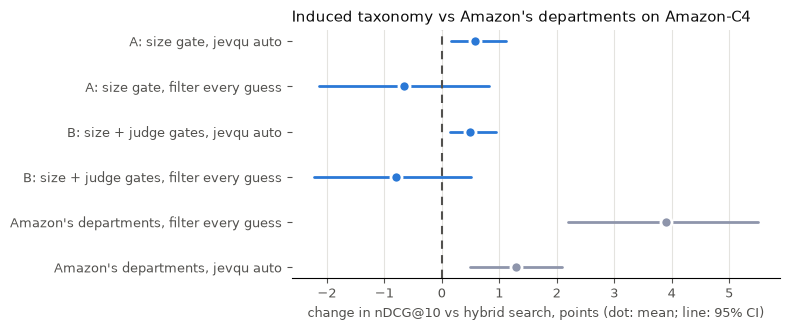

In [8]:
BLUE, INK, MUTED, GRID, GREY = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df", "#8e95ab"
names = list(results) + [f"Amazon's departments, {k}" for k in REFERENCE]
vals = [(v["change"], *v["ci"]) for v in results.values()] + list(REFERENCE.values())
fig, ax = plt.subplots(figsize=(8, 3.4))
ys = list(range(len(names)))[::-1]
for y, name, (d, lo, hi) in zip(ys, names, vals):
    color = GREY if name.startswith("Amazon") else BLUE
    ax.plot([100 * lo, 100 * hi], [y, y], color=color, lw=2, solid_capstyle="round")
    ax.plot(100 * d, y, "o", color=color, ms=8, markeredgecolor="white", markeredgewidth=2)
ax.axvline(0, color=MUTED, lw=1.5, ls=(0, (4, 3)))
ax.set_yticks(ys, names)
ax.set_xlabel("change in nDCG@10 vs hybrid search, points (dot: mean; line: 95% CI)", color=MUTED, fontsize=9)
ax.set_title("Induced taxonomy vs Amazon's departments on Amazon-C4", loc="left", color=INK, fontsize=11)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## 6. What the induced classes look like

For each kept class: how many items Jev labeled with it, which Amazon departments those items come from, and three example items. Then how the queries used them.

In [9]:
members = defaultdict(list)
for d in catalog:
    for c in stored[pid[d["item_id"]]].get("classes") or []:
        members[c].append(d)
rows = ["| class | in B | items | top Amazon departments | examples |", "|---|---|---|---|---|"]
for c in sorted(tax_a.classes, key=lambda c: -len(members[c.id])):
    ds = members[c.id]
    top = ", ".join(f"{k} {n / max(1, len(ds)):.0%}" for k, n in Counter(d["category"] for d in ds).most_common(2))
    ex = "; ".join(title(d)[:45] for d in ds[:3])
    rows.append(f"| {c.name} | {'yes' if c.id in b_ids else 'no'} | {len(ds):,} | {top} | {ex} |")
display(Markdown("\n".join(rows)))

top_q = [max(u.classes, key=lambda kv: kv[1]) if u.classes else (None, 0.0) for u in us]
hit = [p >= 0.6 for _, p in top_q]
print(f"queries with a class at P >= 0.6: {np.mean(hit):.0%}; at P >= 0.9: {np.mean([p >= 0.9 for _, p in top_q]):.0%}")
name_of = {c.id: c.name for c in tax_a.classes}
for i in [i for i, h in enumerate(hit) if h][:4]:
    cid, p = top_q[i]
    f = build_filter(us[i], tax_a, "auto")
    kept_target = cid in (stored[next(iter(relevant[i]))].get("classes") or [])
    print(f'\n"{qtexts[i][:110]}..."\n   top class: {name_of[cid]} (P={p:.2f}); '
          f"filter: {[c.match.value for c in f.must] if f else None}; target item has this class: {kept_target}")

| class | in B | items | top Amazon departments | examples |
|---|---|---|---|---|
| Shoes Women Men Shoe | yes | 701 | Clothing 95%, Household 2% | EMU Australia Wrenlette Womens Slippers Sheep; rosyclo Women's Platform Ankle Boots Elasticl; CIOR Kids Sneakers Boys Girls Lightweight Spo |
| Storage Organizer Holder Shelf | no | 625 | Home 48%, Tools 8% | BingoHive Automatic Soda Can Organizer for Re; skiguard Ski Wall Storage Rack: Snowboard Wal; PC Gaming Headset Headphone Hook Holder Hange |
| Replacement Compatible Oem Vehicle | yes | 540 | Automotive 80%, Garden 10% | BuiltRight Industries Rear Seat Release for F; Marsauto DE3175 31mm LED Interior Dome Light ; Redcat 13859 Transmission Gear Set |
| Review Author Book Guide | yes | 530 | Kindle 53%, Books 46% | Finding Karen Black: Roots Become Wings; Lovely Girls: A Thriller; Fair Catch: An Enemies-to-Lovers Roommate Spo |
| Led Light Lights Lighting | yes | 523 | Tools 65%, Automotive 11% | Alladinbox 17 Inch Window Silhouette Lighted ; Battery Operated Wall Sconce, Wireless Wall L; Renyqatt Cool LED Light Up Glasses - 7 Color  |
| Bag Bags Travel Storage | yes | 434 | Clothing 28%, Home 16% | THE COLLECTION ROYAL Crossbody Bag for Women,; WISELIFE 3 Pack Reusable Grocery Bags Large S; Trunk Organizer with Cooler, Collapsible Trun |
| Toys Kids Toy Boys | yes | 351 | Toys 85%, Sports 4% | Effacera Fidget Toys Fidgets Spinners for Kid; plplaaobo Simulation Cat Simulation, Stuffed ; Snuggie Buggies Stuffed Animal Bear in a Lion |
| Author Review Book Books | yes | 307 | Kindle 53%, Books 47% | Finding Karen Black: Roots Become Wings; Lovely Girls: A Thriller; Windows on Humanity: A History of How Art Ref |
| Women Sleeve Neck Tops | yes | 275 | Clothing 94%, Sports 4% | Fairy Grunge Aesthetic Shirts Tops for Women ; Sanderson Sisters Shirt Womens Funny Hallowee; ZAFUL Women's High Neck Cutout Cold Shoulder  |
| Christmas Party Decoration Decorations | yes | 258 | Home 72%, Tools 9% | Alladinbox 17 Inch Window Silhouette Lighted ; Ollny Christmas Lights Outdoor String Lights ; Red Co |
| Dog Dogs Collar Pet | no | 239 | Pet 90%, Sports 3% | TrainPro PRO998 Electronic Dog Training Shock; Didog Personalized Dog Collar and 5ft Leash S; MLB Los Angeles Angels Reflective Dog Leash,  |
| Kitchen Food Stainless Steel | yes | 226 | Home 85%, Tools 5% | Shun Cutlery Premier 9” Bread Knife; Effortle; 1Zpresso JX S Manual Coffee Grinder Silver wi; ORIGENUIN Set of 4 Premium Stainless Steel Ta |
| Women Men Bands Band | no | 197 | Clothing 31%, Care 14% | Braxley Bands Apple Watch Bands, Stretchy and; GEAK 15 Pack Compatible with Apple Watch Band; Compatible with Big Apple Watch 42mm, 44mm, 4 |
| Coffee Mug Cup Tea | yes | 192 | Home 64%, Food 31% | Encheng Glass Mugs Set,Clear Coffee Mugs With; Tea's Tea Green Tea, Rose, 16.9 fl oz; Racer Red Party Cup Doublewall Insulated 32 O |
| Case Cover Phone Iphone | yes | 184 | Cell 96%, Electronics 3% | ORETECH for iPhone 13 Case, with [2 pcs Glass; ROPIGO iPhone 12 Pro Max Wallet Case | Butter; Case Compatible with iphone 7 Case ,Qissy® Ul |
| Book Romance Review Author | no | 181 | Kindle 82%, Books 18% | Strict Confidence (Rochester Trilogy Book 2); Finding Karen Black: Roots Become Wings; Fair Catch: An Enemies-to-Lovers Roommate Spo |
| Men Shirt Fit Sleeve | yes | 178 | Clothing 85%, Sports 12% | Faherty Men's Short Sleeve Heather Henley; Mr LiZhGang Funny Friends Halloween Men's T-S; Pittsburgh Penguins Hockey Reebok NHL Face Of |
| Gift Gifts Love Cards | no | 151 | Home 30%, Office 23% | WESAPPINC 4Pack 3D Greeting cards Pop Up Holi; Deluxe Gift Sets for Women, Gift Set [with Sm; 24 Unique Christmas Cards with Envelopes Wint |
| Chair Table Room Modern | yes | 125 | Home 86%, Garden 8% | Plentio C Shaped Side Table with Charging Sta; H.VERSAILTEX Stretch Dining Chair Covers Set ; LUCKYERMORE Mid-Century Dining Chairs Set of  |
| Sound Audio Stereo Bluetooth | yes | 113 | Electronics 88%, Instruments 6% | Timekettle M2 Language Translator Earbuds - S; LARKSOUND All-in-One 2.1 Sound Bar for TV, 36; Ear Clips Ear Buds Bone Conduction Earbuds fo |
| Dog Pet Toy Dogs | yes | 104 | Pet 85%, Toys 7% | Hyperflite Jawz Black Competition Dog Disc 8.; Hyper Pet IQ Treat lick mat for Dogs, Dog Slo; Giant Dog Rope Chew Toys for Extra Large Dogs |
| Steel Tool Set Cutting | yes | 103 | Tools 46%, Home 26% | Shun Cutlery Premier 9” Bread Knife; Effortle; Professional 440C 5 in 1 Dog Grooming Scissor; Hair Cutting Scissors, Professional Barber Ha |
| Skin Oil Hair Natural | yes | 87 | Care 87%, Household 6% | Carol's Daughter Born To Repair 60-Second Moi; High-Performance Oil Blotting Sheets for Face; Dionis Goat Milk Skincare Lavender Blossom Sc |
| Curtain Inch Room Window | yes | 71 | Home 99%, Garden 1% | Sheer Star Curtains 63 inch Long Light Grey W; Magnetic Curtain Tiebacks 2 Pack Curtain Hold; Rutterllow Blackout Curtains with Silver Snow |

queries with a class at P >= 0.6: 25%; at P >= 0.9: 11%

"I need to find a product that would make a great stocking stuffer. They should come in cute individually wrapp..."
   top class: Gift Gifts Love Cards (P=0.66); filter: None; target item has this class: False

"I am looking for a book that is a great read, written very well, and captivating enough to read in one sitting..."
   top class: Author Review Book Books (P=0.69); filter: None; target item has this class: False

"I need light bulbs that are bright and don't flicker. I want them to last a long time, preferably around 13 ye..."
   top class: Led Light Lights Lighting (P=0.97); filter: ['led-light-lights-lighting']; target item has this class: True

"I need to find some hooks that work well for hanging hand towels. They should be budget-friendly and reliable...."
   top class: Storage Organizer Holder Shelf (P=0.74); filter: None; target item has this class: True


In [10]:
out = {"classifier": JEV_MODEL if USE_JEV else "offline", "sample": SAMPLE, "k": K,
       "candidates": [{**r, **{k: b[r["id"]].get(k) for k in ("popular", "coherent")}, "kept_b": b[r["id"]]["kept"],
                       "rejected_by_b": b[r["id"]]["rejected_by"]} for r in report_a],
       "kept_a": [c.name for c in tax_a.classes], "kept_b": [c.name for c in tax_b.classes],
       "baseline": {"ndcg10": float(np.mean(base_ndcg)), "recall20": float(np.mean(base_rec))},
       "results": results, "reference_departments": REFERENCE, "spent_usd": spent() if USE_JEV else 0.0}
(DATA / "induction_results.json").write_text(json.dumps(out, indent=1, default=float))
print(f"saved data/c4/induction_results.json" + (f"; spent ${spent():.2f} on Jev in this notebook" if USE_JEV else ""))

saved data/c4/induction_results.json; spent $2.39 on Jev in this notebook
